In [1]:
from google.colab import drive
import sys
drive.mount("/content/drive")
sys.path.append("/content/drive/MyDrive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from rich.traceback import install
install()

import gc
import json
from pathlib import Path

import cv2
import numpy as np
import torch
from skimage import io

from setup_helper import (
    DRIVE_BASE, INPUT_DIR, OUTPUT_DIR,
    download_repos_and_setup,
    show_image, plot_masks,
)
from alignment_helpers import (
    load_image,
    find_roi_with_origins,
    save_search_regions, load_search_regions,
    tile_flm,
    save_tiles, load_tiles_manifest,
    save_images_to_dir,
    filter_with_threshold,
    process_tem_image,
    generate_tem_masks,
    run_lightglue_matching, save_match_records,
    build_alignment_results,
    visualize_overlay,
    save_result_bundle,
    MatchRecord,
)

# ── Inputs ───────────────────────────────────────────────────────────────────
FLM_STACK_PATH = INPUT_DIR / "FLM-stack_JEY002_G3_L3.tif"
TEM_IMAGE_PATH = INPUT_DIR / "JEY002_G3_L3_1950x_t-13.tif"

flm_pixel_nm   = 121.0
tem_pixel_nm   = 6.9
expected_scale = flm_pixel_nm / tem_pixel_nm

# ── Output tree ──────────────────────────────────────────────────────────────
FLM_FRAMES_DIR = OUTPUT_DIR / "flm_frames"
TEM_DIR        = OUTPUT_DIR / "tem"
MATCHES_DIR    = OUTPUT_DIR / "matches"
RESULTS_DIR    = OUTPUT_DIR / "results"

for d in [FLM_FRAMES_DIR, TEM_DIR, MATCHES_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [3]:
download_repos_and_setup()

✓ All repos ready.


  TEM intermediates saved → /content/drive/MyDrive/output/tem/processing


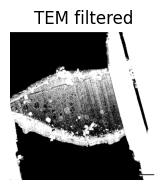

✓ SAM loaded.
  Generated 10 TEM masks → /content/drive/MyDrive/output/tem/masks


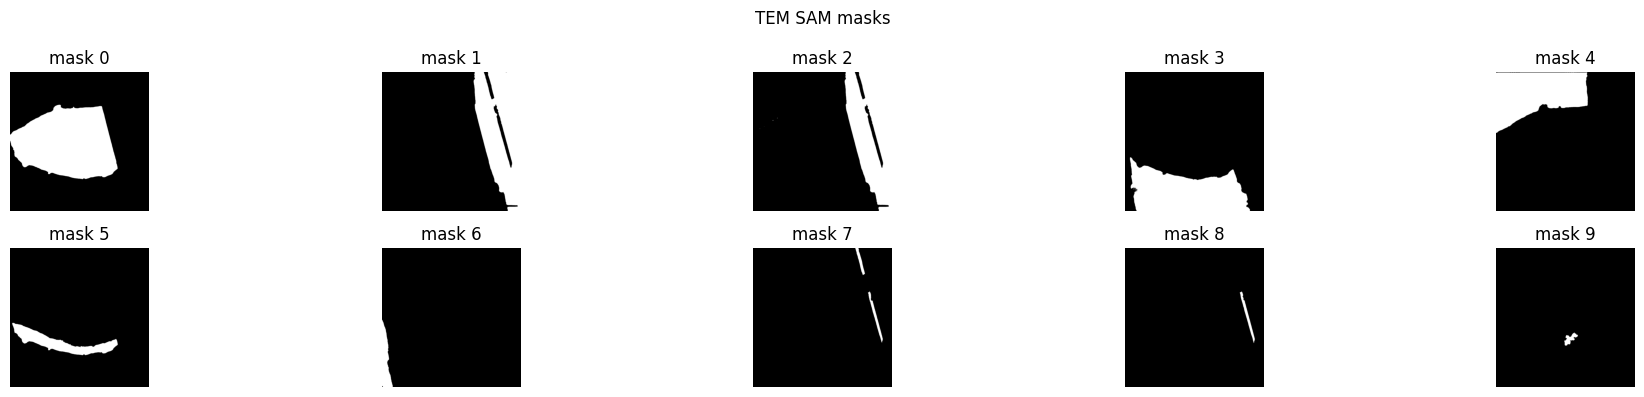

Done – TEM processing.


In [4]:
#  Reads   : TEM image
#  Writes  : tem/processing/  and  tem/masks/
#  Memory  : SAM model loaded, masks generated, model deleted

from setup_helper import load_sam_model

TEM_PROC_DIR  = TEM_DIR / "processing"
TEM_MASKS_DIR = TEM_DIR / "masks"

if not (TEM_PROC_DIR / "tem_filtered.png").exists():
    process_tem_image(TEM_IMAGE_PATH, threshold=130, out_dir=TEM_PROC_DIR)
else:
    print("TEM filtered image already on disk.")

tem_filtered = cv2.imread(str(TEM_PROC_DIR / "tem_filtered.png"), cv2.IMREAD_GRAYSCALE)
tem_gray_u8  = cv2.imread(str(TEM_PROC_DIR / "tem_gray.png"),     cv2.IMREAD_GRAYSCALE)
show_image(tem_filtered, title="TEM filtered", figsize=(2, 2))


if len(list(TEM_MASKS_DIR.glob("mask_*.png"))) == 0:
    sam_model, mask_generator = load_sam_model()
    generate_tem_masks(mask_generator, tem_filtered, TEM_MASKS_DIR, top_k=10)
    del sam_model, mask_generator
    torch.cuda.empty_cache()
    gc.collect()
else:
    print("TEM masks already on disk.")

del tem_gray_u8
gc.collect()

# quick visual check
tem_masks_preview = [
    cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
    for p in sorted(TEM_MASKS_DIR.glob("mask_*.png"))
]
plot_masks(tem_masks_preview, ncols=5, title="TEM SAM masks")
del tem_masks_preview
gc.collect()
print("Done – TEM processing.")

In [5]:
from shapely.geometry import box

flm_stack = io.imread(str(FLM_STACK_PATH))
img_tem   = io.imread(str(TEM_IMAGE_PATH))

# collect all ROIs across all frames with their bounding boxes and laplacian
all_rois = []  # list of {frame_idx, origin, bbox, laplacian}

for frame_idx in range(flm_stack.shape[0]):
    flm_frame = flm_stack[frame_idx]
    crops, origins = find_roi_with_origins(flm_frame, img_tem, flm_pixel_nm, tem_pixel_nm, pad_factor=1)

    for crop, (ox, oy) in zip(crops, origins):
        if crop.max() == crop.min(): # if the values are all same then the image cannot be normalized from uint16 to uint8 because it will lead to division by zero error
            continue
        h, w = crop.shape[:2]
        crop_u8 = ((crop - crop.min()) / (crop.max() - crop.min()) * 255).astype(np.uint8)
        lap = cv2.Laplacian(crop_u8, cv2.CV_64F).var()
        mean_intensity = crop.mean()
        all_rois.append({
            "frame_idx": frame_idx,
            "origin":    (ox, oy),
            "bbox":      (ox, oy, ox + w, oy + h),  # (x0, y0, x1, y1)
            "laplacian": lap,
            "mean_intensity": mean_intensity,
            "area":      w * h,
        })

del flm_stack, img_tem
gc.collect()

# group by spatial overlap using IoU
def iou(b1, b2):
    ix0 = max(b1[0], b2[0])
    iy0 = max(b1[1], b2[1])
    ix1 = min(b1[2], b2[2])
    iy1 = min(b1[3], b2[3])
    if ix1 <= ix0 or iy1 <= iy0:
        return 0.0
    inter = (ix1 - ix0) * (iy1 - iy0)
    a1    = (b1[2] - b1[0]) * (b1[3] - b1[1])
    a2    = (b2[2] - b2[0]) * (b2[3] - b2[1])
    return inter / (a1 + a2 - inter)

IOU_THRESHOLD = 0.3
groups = []  # list of lists of roi indices
assigned = [False] * len(all_rois)

import networkx as nx

G = nx.Graph()
G.add_nodes_from(range(len(all_rois)))

for i in range(len(all_rois)):
    for j in range(i + 1, len(all_rois)):
        if iou(all_rois[i]["bbox"], all_rois[j]["bbox"]) >= IOU_THRESHOLD:
            G.add_edge(i, j)

groups = list(nx.connected_components(G))

best_per_group = []
for group in groups:
    best_idx = max(group, key=lambda i: all_rois[i]["laplacian"] * all_rois[i]["mean_intensity"])
    best_roi = all_rois[best_idx]
    best_per_group.append(best_roi)
    print(f"ROI group size={len(group):2d}  "
          f"best frame={best_roi['frame_idx']:2d}  "
          f"laplacian={best_roi['laplacian']:.2f}  "
          f"mean_intensity={best_roi['mean_intensity']:.2f}  "
          f"bbox={best_roi['bbox']}")

frames_to_process = sorted(set(r["frame_idx"] for r in best_per_group))
print(f"\nFrames to process: {frames_to_process}")

ROI group size=21  best frame= 6  laplacian=206.66  mean_intensity=730.07  bbox=(1506, 0, 2000, 351)
ROI group size=21  best frame=11  laplacian=119.05  mean_intensity=699.47  bbox=(825, 365, 1770, 1599)
ROI group size=21  best frame= 0  laplacian=314.85  mean_intensity=552.77  bbox=(1759, 1799, 2000, 2000)
ROI group size=19  best frame=10  laplacian=240.28  mean_intensity=501.86  bbox=(567, 1741, 897, 2000)

Frames to process: [0, 6, 10, 11]


In [6]:
# input from the experimenter — approximate FLM pixel location of TEM field of view
tem_location_in_flm = (1200, 800)  # (x, y) — experimenter fills this in

# find which ROI group contains this point
def point_in_bbox(point, bbox):
    x, y = point
    x0, y0, x1, y1 = bbox
    return x0 <= x <= x1 and y0 <= y <= y1

relevant_group = None
for group, best_roi in zip(groups, best_per_group):
    if point_in_bbox(tem_location_in_flm, best_roi["bbox"]):
        relevant_group = group
        relevant_roi   = best_roi
        break

if relevant_group is None:
    print("Point not found in any ROI — check tem_location_in_flm")
else:
    best_frame = relevant_roi["frame_idx"]
    print(f"Relevant ROI: {relevant_roi['bbox']}")
    print(f"Best frame: {best_frame}  laplacian={relevant_roi['laplacian']:.2f}")
    frames_to_process = [best_frame]

Relevant ROI: (825, 365, 1770, 1599)
Best frame: 11  laplacian=119.05


In [7]:
sr_dir = FLM_FRAMES_DIR / f"frame_{str(best_frame).zfill(2)}" / "search_regions"

if (sr_dir / "meta.json").exists():
    print(f"Frame {best_frame}: already done, skipping.")
else:
    flm_stack = io.imread(str(FLM_STACK_PATH))
    flm_frame = flm_stack[best_frame]

    # use only the relevant ROI crop, not all ROIs in the frame
    ox, oy = relevant_roi["origin"]
    x0, y0, x1, y1 = relevant_roi["bbox"]
    crop = flm_frame[y0:y1, x0:x1, 1]  # reflection channel

    save_search_regions([crop], [(ox, oy)], sr_dir)
    print(f"Frame {best_frame}: 1 search region saved.")

    del flm_stack, flm_frame, crop
    gc.collect()

print("Done – search regions.")

  Saved 1 search regions → /content/drive/MyDrive/output/flm_frames/frame_11/search_regions
Frame 11: 1 search region saved.
Done – search regions.


In [8]:
#  Reads   : search_regions/ from disk + TEM image (sizing only)
#  Writes  : flm_frames/frame_XX/tiles/{*.png, manifest.json}

img_tem   = io.imread(str(TEM_IMAGE_PATH))
frame_dir = FLM_FRAMES_DIR / f"frame_{str(best_frame).zfill(2)}"
tiles_dir = frame_dir / "tiles"

if (tiles_dir / "manifest.json").exists():
    print(f"Frame {best_frame}: tiles already done, skipping.")
else:
    crops, origins = load_search_regions(frame_dir / "search_regions")
    tiles_per_sr = [
        tile_flm(crop, img_tem, flm_pixel_nm=flm_pixel_nm,
                 tem_pixel_nm=tem_pixel_nm, tile_scale=2, use_hist_eq=True)
        for crop in crops
    ]
    save_tiles(tiles_per_sr, origins, tiles_dir)
    n_tiles = sum(len(t) for t in tiles_per_sr)
    print(f"Frame {best_frame}: {n_tiles} tiles saved.")

    del crops, origins, tiles_per_sr
    gc.collect()

del img_tem
gc.collect()
print("Done – tiles.")

  Saved 165 tiles → /content/drive/MyDrive/output/flm_frames/frame_11/tiles
Frame 11: 165 tiles saved.
Done – tiles.


In [9]:
from setup_helper import load_swinir_model, swinir_upscale

frame_dir    = FLM_FRAMES_DIR / f"frame_{str(best_frame).zfill(2)}"
up_dir       = frame_dir / "tiles_upscaled"
tile_images, manifest = load_tiles_manifest(frame_dir / "tiles")
names = [m["file"] for m in manifest]

if all((up_dir / n).exists() for n in names):
    print(f"Frame {best_frame}: upscaled tiles already done, skipping.")
else:
    swinir_model = load_swinir_model()
    print(f"Frame {best_frame}: upscaling {len(tile_images)} tiles …")
    upscaled = swinir_upscale(swinir_model, tile_images, window_size=8, max_batch_size=4)
    save_images_to_dir(upscaled, names, up_dir)
    del swinir_model, upscaled
    torch.cuda.empty_cache()
    gc.collect()

del tile_images, manifest
gc.collect()
print("Done – upscaling.")

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


✓ SwinIR loaded from 002_lightweightSR_DIV2K_s64w8_SwinIR-S_x4.pth
Frame 11: upscaling 165 tiles …
Done – upscaling.


In [10]:
# STEP 4 – Threshold filter
frame_dir = FLM_FRAMES_DIR / f"frame_{str(best_frame).zfill(2)}"
up_dir    = frame_dir / "tiles_upscaled"
filt_dir  = frame_dir / "tiles_filtered"
_, manifest = load_tiles_manifest(frame_dir / "tiles")
names = [m["file"] for m in manifest]

if all((filt_dir / n).exists() for n in names):
    print(f"Frame {best_frame}: filtered tiles already done, skipping.")
else:
    filt_dir.mkdir(parents=True, exist_ok=True)
    for name in names:
        img = cv2.imread(str(up_dir / name))
        if img is None:
            continue
        gray     = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        filtered = filter_with_threshold(gray, threshold=130)
        cv2.imwrite(str(filt_dir / name), filtered)
        del img, gray, filtered
    gc.collect()

del manifest
gc.collect()
print("Done – filtering.")

Done – filtering.


In [11]:
from setup_helper import load_lightglue_models

match_dir = MATCHES_DIR / f"frame_{str(best_frame).zfill(2)}"

if (match_dir / "match_meta.json").exists():
    print(f"Frame {best_frame}: matches already done, skipping.")
else:
    _, manifest = load_tiles_manifest(FLM_FRAMES_DIR / f"frame_{str(best_frame).zfill(2)}" / "tiles")
    filt_dir    = FLM_FRAMES_DIR / f"frame_{str(best_frame).zfill(2)}" / "tiles_filtered"

    extractor, matcher = load_lightglue_models(filter_threshold=0.05)
    records = run_lightglue_matching(
        extractor, matcher,
        tiles_filtered_dir = filt_dir,
        tile_manifest      = manifest,
        masks_dir          = TEM_MASKS_DIR,
        frame_idx          = best_frame,
        device             = device,
    )
    save_match_records(records, match_dir)
    print(f"Frame {best_frame}: {len(records)} pairs saved.")

    del extractor, matcher, records, manifest
    torch.cuda.empty_cache()
    gc.collect()

print("Done – matching.")

✓ SuperPoint + LightGlue loaded.
  Frame 11: 911 tile-mask pairs with ≥1 match
Frame 11: 911 pairs saved.
Done – matching.


In [12]:
match_dir = MATCHES_DIR / f"frame_{str(best_frame).zfill(2)}"

with open(match_dir / "match_meta.json") as f:
    stored_meta = json.load(f)

all_records = []
for i, m in enumerate(stored_meta):
    npz = np.load(str(match_dir / m["npz_file"]))
    all_records.append(MatchRecord(
        frame_idx     = m["frame_idx"],
        sr_idx        = m["sr_idx"],
        sr_origin_x   = m["sr_origin_x"],
        sr_origin_y   = m["sr_origin_y"],
        tile_origin_x = m["tile_origin_x"],
        tile_origin_y = m["tile_origin_y"],
        tem_mask_idx  = m["tem_mask_idx"],
        m_kpts_tem    = npz["m_kpts_tem"],
        m_kpts_tile   = npz["m_kpts_tile"],
        scores        = npz["scores"],
        n_matches     = m["n_matches"],
        tile_img_path = m["tile_img_path"],
        mask_img_path = m["mask_img_path"],
    ))

all_records.sort(key=lambda r: r.n_matches, reverse=True)

for i, rec in enumerate(all_records[:10]):
    print(f"Rank {i+1}: n_matches={rec.n_matches}  "
          f"tem_mask={rec.tem_mask_idx}  "
          f"tile=({rec.tile_origin_x}, {rec.tile_origin_y})  "
          f"tile_path={rec.tile_img_path}  "
          f"mask_path={rec.mask_img_path}")

best_record = all_records[0]

Rank 1: n_matches=58  tem_mask=5  tile=(0, 539)  tile_path=/content/drive/MyDrive/output/flm_frames/frame_11/tiles_filtered/00077.png  mask_path=/content/drive/MyDrive/output/tem/masks/mask_05.png
Rank 2: n_matches=47  tem_mask=5  tile=(539, 616)  tile_path=/content/drive/MyDrive/output/flm_frames/frame_11/tiles_filtered/00095.png  mask_path=/content/drive/MyDrive/output/tem/masks/mask_05.png
Rank 3: n_matches=39  tem_mask=0  tile=(77, 385)  tile_path=/content/drive/MyDrive/output/flm_frames/frame_11/tiles_filtered/00056.png  mask_path=/content/drive/MyDrive/output/tem/masks/mask_00.png
Rank 4: n_matches=37  tem_mask=5  tile=(231, 924)  tile_path=/content/drive/MyDrive/output/flm_frames/frame_11/tiles_filtered/00135.png  mask_path=/content/drive/MyDrive/output/tem/masks/mask_05.png
Rank 5: n_matches=37  tem_mask=5  tile=(385, 924)  tile_path=/content/drive/MyDrive/output/flm_frames/frame_11/tiles_filtered/00137.png  mask_path=/content/drive/MyDrive/output/tem/masks/mask_05.png
Rank 6: 

n_matches=27  tile=/content/drive/MyDrive/output/flm_frames/frame_11/tiles_filtered/00056.png  mask=/content/drive/MyDrive/output/tem/masks/mask_05.png


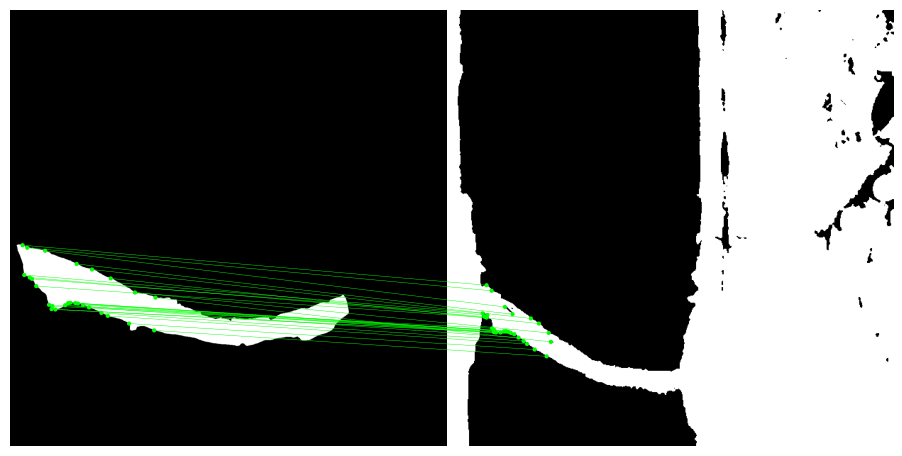

In [17]:
from lightglue import viz2d
import matplotlib.pyplot as plt

match_dir = MATCHES_DIR / f"frame_{str(best_frame).zfill(2)}"

with open(match_dir / "match_meta.json") as f:
    stored_meta = json.load(f)

target_tile = "00056.png"
target_mask = "mask_05.png"
meta = next(
    entry for entry in stored_meta
    if Path(entry["tile_img_path"]).name == target_tile
    and Path(entry["mask_img_path"]).name == target_mask
)

npz  = np.load(str(match_dir / meta["npz_file"]))

tile_img = cv2.imread(meta["tile_img_path"], cv2.IMREAD_GRAYSCALE)
tem_mask = cv2.imread(meta["mask_img_path"], cv2.IMREAD_GRAYSCALE)

m_kpts_tem  = torch.from_numpy(npz["m_kpts_tem"])
m_kpts_tile = torch.from_numpy(npz["m_kpts_tile"])

print(f"n_matches={meta['n_matches']}  tile={meta['tile_img_path']}  mask={meta['mask_img_path']}")

axes = viz2d.plot_images([tem_mask, tile_img])
viz2d.plot_matches(m_kpts_tem, m_kpts_tile, color="lime", lw=0.3)
plt.show()

Transform M:
[[ 1.39954187e+01  2.57120200e+00 -1.48971519e+04]
 [-2.57120200e+00  1.39954187e+01 -8.80362834e+03]]
Scale: 14.22965  (expected 17.53623)


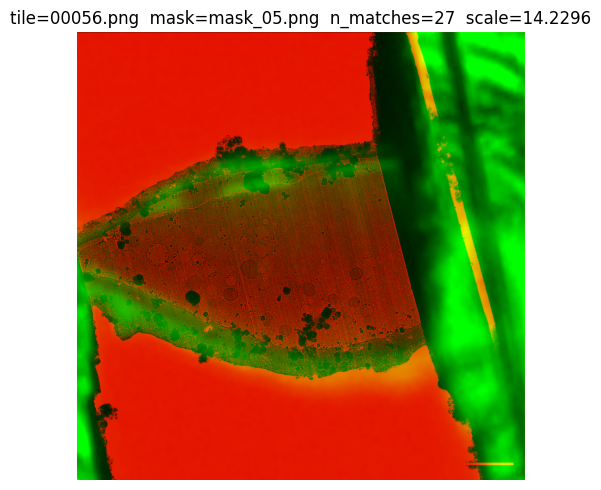

2457

In [18]:
from alignment_helpers import backproject_to_full_flm, matrix_scale

kpts_flm_full = backproject_to_full_flm(
    npz["m_kpts_tile"],
    (meta["tile_origin_x"], meta["tile_origin_y"]),
    (meta["sr_origin_x"],   meta["sr_origin_y"]),
    upscale_factor=4,
)
M, _ = cv2.estimateAffinePartial2D(
    kpts_flm_full.astype(np.float32),
    npz["m_kpts_tem"].astype(np.float32),
)
scale = matrix_scale(M)
print(f"Transform M:\n{M}")
print(f"Scale: {scale:.5f}  (expected {expected_scale:.5f})")

img_tem  = io.imread(str(TEM_IMAGE_PATH))
tem_gray = img_tem[:, :, 0] if img_tem.ndim == 3 else img_tem
tem_u8   = ((tem_gray.astype(float) / (tem_gray.max() + 1e-8)) * 255).astype(np.uint8)

flm_stack  = io.imread(str(FLM_STACK_PATH))
frame_refl = flm_stack[best_frame, :, :, 1]
frame_u8   = ((frame_refl.astype(float) / (frame_refl.max() + 1e-8)) * 255).astype(np.uint8)

del img_tem, tem_gray, flm_stack, frame_refl
gc.collect()

visualize_overlay(frame_u8, tem_u8, M, title=f"tile={Path(meta['tile_img_path']).name}  mask={Path(meta['mask_img_path']).name}  n_matches={meta['n_matches']}  scale={scale:.4f}")

del frame_u8, tem_u8
gc.collect()